# Basic NLP with `text_records()`

This notebook shows a simple handoff from `crategraph` to an NLP library.

The point of using `crategraph` here is that we do not read every file directly. We use the RO-Crate graph to select file entities, annotate those files with genre metadata from related entities, keep provenance and entity metadata with `text_records()`, then group the NLP results by that graph-derived genre.


## Install TextBlob

Run this cell once if TextBlob is not already available in your notebook environment.

In [1]:
!uv pip install textblob

Resolved 6 packages in 52ms                                          
Installed 6 packages in 30ms                                
 + click==8.4.0
 + joblib==1.5.3
 + nltk==3.9.4
 + regex==2026.5.9
 + textblob==0.20.0
 + tqdm==4.67.3


In [2]:
import re
from pathlib import Path

import pandas as pd
from textblob import TextBlob

from crategraph import Crate

## Load the crate

Load the Australian Corpus of English crate from `data/`.

In [3]:
crate = Crate(Path("../../data/ldaca/Australian_Corpus_of_English"))
crate.summary()

=== Graph Summary ===
Source: ../../data/ldaca/Australian_Corpus_of_English
Entities: 2582 | Relationships: 11952

Entity types:
  File              1717  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  RepositoryObject   850  ▒▒▒▒▒▒▒
  DefinedTerm          5  
  CreativeWork         1  
  Organization         1  
  +8 more

Relationship types:
  license                 2568  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  ldac:communicationMode  2567  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  hasPart                 2550  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  ldac:linguisticGenre    1714  ▒▒▒▒▒▒▒▒▒▒
  ldac:indexableText       850  ▒▒▒▒▒
  +5 more

Most connected: Attribution 4.0 International (CC BY 4.0) (2568), WrittenLanguage (2567), Report (1173)

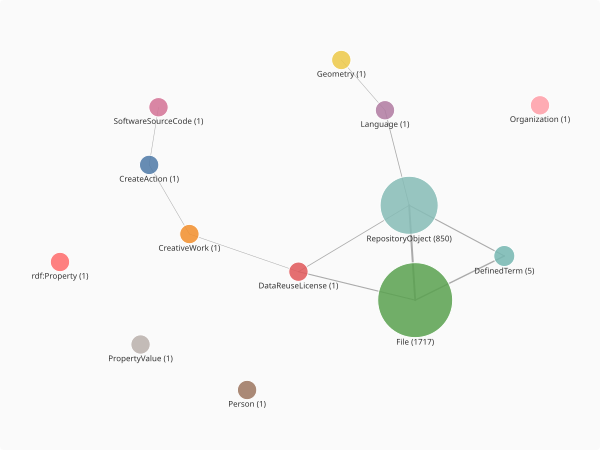

In [5]:
crate.glimpse()

## Annotate files with graph-derived genre

Start with file entities, then derive a `genre` property from the file-to-genre relationship recorded in the crate. The annotation is a graph transform, so the derived field behaves like any other entity property in later filtering and record export.


In [6]:
def genre_label(entity):
    return entity.related("ldac:linguisticGenre").join("name")


tagged = crate.annotate_entities(genre=genre_label)
text_files = tagged.select(entity_types=["File"])
text_files.summary()

=== Graph Summary ===
Source: ../../data/ldaca/Australian_Corpus_of_English
Entities: 1717 | Relationships: 0

Entity types:
  File  1717  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Most connected: F05#Text (0), A33d#Raw (0), A13e#Text (0)

In [13]:
len(list(tagged.text_records()))

inspect(E12-raw.txt) failed: File conversion failed after 1 attempts:
 - PlainTextConverter threw UnicodeDecodeError with message: 'ascii' codec can't decode byte 0xc2 in position 8675: ordinal not in range(128)

inspect(E12-plain.txt) failed: File conversion failed after 1 attempts:
 - PlainTextConverter threw UnicodeDecodeError with message: 'ascii' codec can't decode byte 0xc2 in position 8464: ordinal not in range(128)

inspect(E18a-raw.txt) failed: File conversion failed after 1 attempts:
 - PlainTextConverter threw UnicodeDecodeError with message: 'ascii' codec can't decode byte 0xc2 in position 9566: ordinal not in range(128)

inspect(E18a-plain.txt) failed: File conversion failed after 1 attempts:
 - PlainTextConverter threw UnicodeDecodeError with message: 'ascii' codec can't decode byte 0xc2 in position 9398: ordinal not in range(128)

inspect(E27a-raw.txt) failed: File conversion failed after 1 attempts:
 - PlainTextConverter threw UnicodeDecodeError with message: 'ascii' co

1680

Use ordinary entity records to inspect the new property and choose a small, deterministic sample before extracting file text.


In [7]:
file_table = pd.DataFrame(text_files.entity_records())

genre_counts = (
    file_table.dropna(subset=["genre"]).groupby("genre").size().sort_values(ascending=False)
)

genre_counts

genre
Report           592
Informational    189
Narrative         65
Ludic             18
dtype: int64

In [8]:
sampled_entity_ids = (
    file_table.dropna(subset=["genre"])
    .sort_values(["genre", "id"])
    .groupby("genre", group_keys=False)
    .head(15)["id"]
    .tolist()
)

sampled_entity_ids[:5], len(sampled_entity_ids)

(['D03-plain.txt',
  'D03-raw.txt',
  'D04-plain.txt',
  'D06-plain.txt',
  'D06-raw.txt'],
 60)

## Hand the text to NLP tools

`text_records()` returns one row-like record per text unit, with provenance columns kept alongside the text. Because `annotate_entities()` wrote `genre` back onto the file entities, `include_properties` can carry both native metadata (`name`) and the derived genre into the same rows.


In [9]:
records = pd.DataFrame(
    text_files.text_records(
        include_properties=["name", "genre"],
        filters={"entity_id": sampled_entity_ids},
    )
)

records[["entity_id", "genre", "name", "text"]].head()

,entity_id,genre,name,text
0,R11-plain.txt,Ludic,R11#Text,Brother Bill By Geoffrey Bingham\n\nWHEN it co...
1,D10a-raw.txt,Informational,D10a#Raw,<subsample>\n\t<id> D10a </id>\n\n\t<source> C...
2,L05-plain.txt,Narrative,L05#Text,By Morris West\n\nThe return flight to Sydney ...
3,L10-raw.txt,Narrative,L10#Raw,<sample>\n\t<id> L10 </id>\n\n\t<note> 2006 wo...
4,K25-plain.txt,Narrative,K25#Text,The suppliant By Graham Sheil\n\nFor a one-tim...


In [10]:
word_pattern = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")


def word_count(text):
    return len(word_pattern.findall(text))


records["word_count"] = records["text"].map(word_count)
records["polarity"] = records["text"].map(lambda text: TextBlob(text).sentiment.polarity)

records[["entity_id", "genre", "word_count", "polarity", "name"]].head()

,entity_id,genre,word_count,polarity,name
0,R11-plain.txt,Ludic,2008,0.063364,R11#Text
1,D10a-raw.txt,Informational,922,0.103079,D10a#Raw
2,L05-plain.txt,Narrative,1997,0.103077,L05#Text
3,L10-raw.txt,Narrative,2026,0.060599,L10#Raw
4,K25-plain.txt,Narrative,2059,0.057747,K25#Text


## Summarise by graph-derived genre

The grouping column comes from RO-Crate relationships, not from file names.

In [11]:
records.groupby("genre").agg(
    documents=("entity_id", "count"),
    mean_words=("word_count", "mean"),
    mean_polarity=("polarity", "mean"),
).sort_values("documents", ascending=False)

,documents,mean_words,mean_polarity
genre,,,
Informational,15,1347.866667,0.100153
Ludic,15,1588.800000,0.064110
Narrative,15,2053.933333,0.080455
Report,15,407.866667,0.097853
